In [2]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["SimHei"],  # 黑体
    "axes.unicode_minus": False
})


datashape: (150, 4)
unique: [0 1 2]
best_k: 8


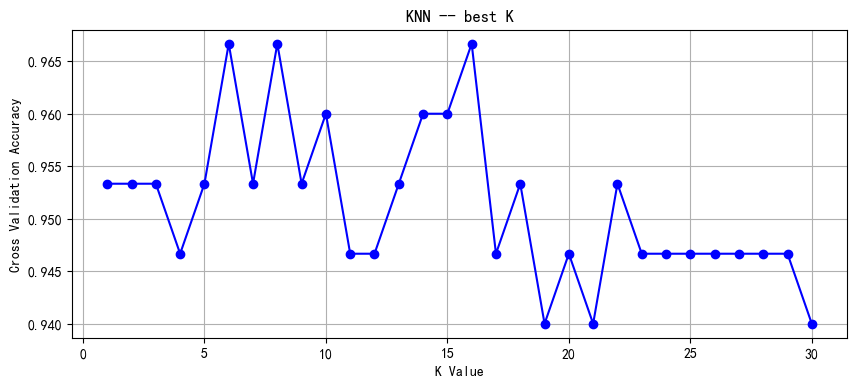

In [7]:
iris = load_iris()
X=iris.data
y=iris.target

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

print("datashape:",X_scaled.shape)
print("unique:",np.unique(y))

#交叉验证K
k_range=range(1,31)
k_scores=[]
for k in k_range:
    knn=KNeighborsClassifier(n_neighbors=k)
    scores=cross_val_score(knn,X_scaled,y,cv=10,scoring='accuracy')
    k_scores.append(scores.mean())

best_k=k_range[np.argmax(k_scores)]
print("best_k:",best_k)

#画k选择曲线
plt.figure(figsize=(10,4))
plt.plot(k_range,k_scores,'b-o')
plt.xlabel('K Value')
plt.ylabel('Cross Validation Accuracy')
plt.title('KNN -- best K')
plt.grid(True)
plt.show()

final model accuracy:0.9667


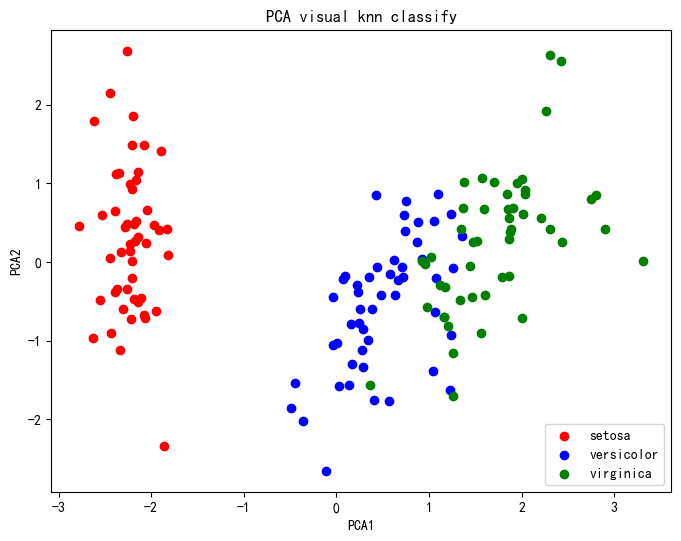

In [15]:
# 开始训练模型
knn_best = KNeighborsClassifier(n_neighbors=best_k)#得到评估器
knn_best.fit(X_scaled,y)
acc=knn_best.score(X_scaled,y)
print(f"final model accuracy:{acc:.4f}")

pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
for i,color in zip(range(3),['red','blue','green']):
    plt.scatter(X_pca[y==i,0],X_pca[y==i,1],c=color,label=iris.target_names[i])
plt.legend()
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('PCA visual knn classify')
plt.show()



In [ ]:
#手动实现逻辑
#pca
#计算协方差矩阵
cov_mat=np.cov(X_scaled.T)#转置：因为其将每一行当作一个特征，得到4*4样本
eigen_vals,eigen_vecs=np.linalg.eig(cov_mat)#
idx=np.argsort(eigen_vals)[::-1]
eigen_vecs_sorted=eigen_vecs[:,idx]
#取前两个特征向量
top2_eigen_vecs=eigen_vecs_sorted[:,:2]
X_pca=X_scaled @ top2_eigen_vecs
# 呃呃，最后我返回去套貌似有一点点问题呃呃，就是看一下这个代码理解一下pca原理

# 4. 手写KNN（支持闵可夫斯基距离）
def knn_predict_single(X_train, y_train, x_test, k, p=2):
    diff = X_train - x_test
    dist = np.sum(np.abs(diff) ** p, axis=1) ** (1 / p)
    k_idx = np.argsort(dist)[:k]
    labels = y_train[k_idx]
    pred = np.bincount(labels).argmax()
    return pred

def knn_score(X_train, y_train, X_test, y_test, k, p=2):
    correct = 0
    for x, y_t in zip(X_test, y_test):
        if knn_predict_single(X_train, y_train, x, k, p) == y_t:
            correct += 1
    return correct / len(X_test)

